# Введение в теорию вероятностей и математическую статистику

*Алла Тамбовцева*

## Нормальное распределение: визуализация и вычисление вероятностей

Импортируем необходимые библиотеки и модули:

* библиотеку `numpy` с сокращённым названием `np` для работы с числовыми массивами;
* модуль `stats` из библиотеки `scipy` для статистических функций;
* модуль `pyplot` с сокращённым названием `plt` для построения графиков.

In [1]:
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt

> Кратко: модуль – это набор полезных функций для связанных задач, библиотека – набор из модулей. В Python есть стандартная библиотека – набор базовых функций типа `print()` для вывода текста на экран или `round()` для округления чисел. Однако для более интересных задач возможностей стандартной библиотеки часто не хватает, поэтому приходится импортировать дополнительные. Некоторые модули/библиотеки импортируют с более короткими названиями с помощью конструкции `import ... as ...`, чтобы при вызове функций не прописывать длинные.

Создадим объект типа *случайная величина*. Пусть нам нужна нормальная случайная величина $X \sim N(120, \sigma = 15)$.

Для создания случайной величины, имеющей нормальное распределение, воспользуемся функцией `norm()` из модуля `stats`. Математическое ожидание указывается в аргументе `loc` (от английского *location* – положение центра распределения), стандартное отклонение – в аргументе `scale` (от английского *scale* – масштаб, величина разброса):

In [2]:
X = stats.norm(loc = 120, scale = 15)

> Если мы просто напишем `stats.norm()`, по умолчанию будет создана стандартная нормальная величина $Z \sim N(0, 1)$.

Сам объект `X` от нас скрыт, при выводе на экран ничего интересного мы в нём не увидим:

In [3]:
print(X) # rv – объект типа random variable

Однако к объекту можно применять разные методы и получать ответы на вопросы. Например, мы можем вычислить значение функции плотности в точке (вероятность попасть в окрестность какого-то значения):

In [4]:
# pdf – probability density function

print(X.pdf(120))
print(X.pdf(190))

0.02659615202676218
4.964030580419994e-07


> Результат `4.964030580419994e-07` – это научная запись числа, `e` здесь – это число 10. Получается, это значение примерно $4.96 \times 10^{-7}$.

Или значение функции распределения в точке, значение накопленной вероятности:

$$
\text{F}(a) = \text{P}(X < a).
$$

In [5]:
# cdf – cumulative distribution function
# P(X < 130)

print(X.cdf(130))

0.7475074624530771


Построим график функции плотности. Так как Python строит графики по точкам, чтобы это сделать, нужно:

* создать набор координат точек по горизонтальной оси (значения `X`);
* создать набор координат точек по вертикальной оси (значения функции плотности для каждого значения `X`);
* соединить точки.

Мы знаем, что нормальная случайная величина может принимать значения от $-\infty$ до $+\infty$. Но при этом, по правилу трёх сигм, 99.8% значений лежат на отрезке $a \pm 3 \times \sigma$, где $a$ – среднее, а $\sigma$ – стандартное отклонение. 

Создадим с помощью функции `linspace()` (от английского *linear space*) из библиотеки `numpy`, которую мы сократили до `np`, массив из 100 равноудалённых точек на отрезке $a \pm 3 \times \sigma$, то есть в нашем случае на отрезке от 75 до 165:

In [6]:
# левая граница, правая граница, число точек,
# итого 100 точек на отрезке, на одинаковом расстоянии (0.91) друг от друга

x_vals = np.linspace(120 - 3 * 15, 120 + 3 * 15, num = 100)
print(x_vals)

[ 75.          75.90909091  76.81818182  77.72727273  78.63636364
  79.54545455  80.45454545  81.36363636  82.27272727  83.18181818
  84.09090909  85.          85.90909091  86.81818182  87.72727273
  88.63636364  89.54545455  90.45454545  91.36363636  92.27272727
  93.18181818  94.09090909  95.          95.90909091  96.81818182
  97.72727273  98.63636364  99.54545455 100.45454545 101.36363636
 102.27272727 103.18181818 104.09090909 105.         105.90909091
 106.81818182 107.72727273 108.63636364 109.54545455 110.45454545
 111.36363636 112.27272727 113.18181818 114.09090909 115.
 115.90909091 116.81818182 117.72727273 118.63636364 119.54545455
 120.45454545 121.36363636 122.27272727 123.18181818 124.09090909
 125.         125.90909091 126.81818182 127.72727273 128.63636364
 129.54545455 130.45454545 131.36363636 132.27272727 133.18181818
 134.09090909 135.         135.90909091 136.81818182 137.72727273
 138.63636364 139.54545455 140.45454545 141.36363636 142.27272727
 143.18181818 144.

> Мы могли выбрать любое количество точек, но если точек будет мало (например, 10), при их соединении мы не получим гладкий «колокольчик» для плотности распределения, а получим ломаную линию. Если точек будет много (например, 1000), мы получим большую точность, но визуально отличий от результата со 100 точками не будет.

Вычислим значения функции плотности в каждой точке `x_vals`:

In [7]:
# 100 значений

density = X.pdf(x_vals)
print(density)

[0.00029546 0.00035372 0.00042192 0.00050142 0.00059372 0.00070043
 0.0008233  0.00096416 0.00112499 0.00130783 0.00151482 0.00174813
 0.00200997 0.00230257 0.00262809 0.00298863 0.00338618 0.00382253
 0.0042993  0.0048178  0.00537905 0.00598365 0.00663181 0.00732323
 0.00805708 0.00883198 0.0096459  0.01049621 0.0113796  0.01229211
 0.01322911 0.01418533 0.0151549  0.01613138 0.01710783 0.01807686
 0.01903074 0.01996151 0.02086104 0.02172117 0.02253384 0.02329121
 0.02398577 0.02461048 0.02515888 0.02562521 0.02600448 0.02629262
 0.02648648 0.02658394 0.02658394 0.02648648 0.02629262 0.02600448
 0.02562521 0.02515888 0.02461048 0.02398577 0.02329121 0.02253384
 0.02172117 0.02086104 0.01996151 0.01903074 0.01807686 0.01710783
 0.01613138 0.0151549  0.01418533 0.01322911 0.01229211 0.0113796
 0.01049621 0.0096459  0.00883198 0.00805708 0.00732323 0.00663181
 0.00598365 0.00537905 0.0048178  0.0042993  0.00382253 0.00338618
 0.00298863 0.00262809 0.00230257 0.00200997 0.00174813 0.00151

Построим график плотности. Для этого воспользуемся функцией `plot()` из модуля `pyplot`, который мы импортировали как `plt`:

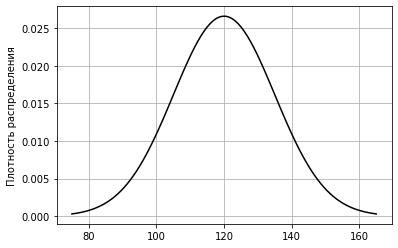

In [8]:
# сначала – координаты по горизонтальной оси, 
# затем – координаты по вертикальной оси,
# color – цвет линии,
# grid – добавление координатной сетки,
# ylabel – добавление подписи по оси y

plt.plot(x_vals, density, color = "black");
plt.grid();
plt.ylabel("Плотность распределения");

Теперь представим, что нам нужно закрасить на графике площадь, соответствующую вероятности $\text{P}(X > 130)$. Чтобы это сделать, нужно ограничить нужную область по горизонтальной и вертикальной оси. Зафиксируем отрезок от 130 до 165 (среднее плюс три стандартных отклонения) – набор из ста точек `interval01`, вычислим в каждой точке значение плотности – `density01`.

In [9]:
interval01 = np.linspace(130, 120 + 3 * 15, num = 100)
density01 = X.pdf(interval01)

Повторим построение графика через `plt.plot()` и добавим к этому ещё одну строчку с функцией `fill_between()`, которая закрашивает область, ограниченную по двум осям:

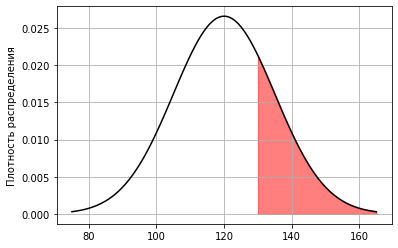

In [10]:
plt.plot(x_vals, density, color = "black");

# по оси X ограничиваем отрезком interval01,
# по оси Y ограничиваем отрезком density01,
# цвет заливки красный (color), 
# плотность цвета 50% (alpha)

plt.fill_between(interval01, density01, color = "red", alpha = 0.5);
plt.grid();
plt.ylabel("Плотность распределения");

Если захотим посчитать эту вероятность, нужно учесть, что метод `.cdf()` считает вероятность $\text{P}(X < 130)$, поэтому для нахождения $\text{P}(X > 130)$ результат необходимо вычесть из 1:

In [11]:
print(1 - X.cdf(130))

0.2524925375469229


Хотя есть и ещё один вариант – вычислить значение *функции дожития* в точке 130, так как:

$$
\text{S}(x) = 1 - \text{F}(x) = 1 - \text{P}(X < x).
$$

In [12]:
# sf() – survival function, функция дожития
print(X.sf(130))

0.2524925375469229
